# 데이터 불러오기

In [1]:
import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# import warnings
# warnings.filterwarnings("ignore")

import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.auto import tqdm
from IPython.display import display

base_path = './'
data_path = os.path.join(base_path, 'data/')
users = pd.read_csv(data_path+'users.csv')
books = pd.read_csv(data_path+'books.csv')
ratings = pd.read_csv(data_path+'train_ratings.csv')

In [2]:
df = ratings.merge(books, on='isbn', how='inner')
df = df.merge(users, on='user_id', how='inner')
df.head()

,user_id,isbn,rating,book_title,book_author,year_of_publication,publisher,img_url,language,category,summary,img_path,location,age
0,8,0002005018,4,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,en,['Actresses'],"In a small town in Canada, Clara Callan reluct...",images/0002005018.01.THUMBZZZ.jpg,"timmins, ontario, canada",NaN
1,67544,0002005018,7,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,en,['Actresses'],"In a small town in Canada, Clara Callan reluct...",images/0002005018.01.THUMBZZZ.jpg,"toronto, ontario, canada",30.0
2,123629,0002005018,8,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,en,['Actresses'],"In a small town in Canada, Clara Callan reluct...",images/0002005018.01.THUMBZZZ.jpg,"kingston, ontario, canada",NaN
3,200273,0002005018,8,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,en,['Actresses'],"In a small town in Canada, Clara Callan reluct...",images/0002005018.01.THUMBZZZ.jpg,"comber, ontario, canada",NaN
4,210926,0002005018,9,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,en,['Actresses'],"In a small town in Canada, Clara Callan reluct...",images/0002005018.01.THUMBZZZ.jpg,"guelph, ontario, canada",NaN


# 평점 분포 검사

=== 평점 분포 (Rating Distribution) ===
----------------------------------------
Rating |      Count | Percentage
----------------------------------------
1      |     13,249 |      4.32%
2      |     12,929 |      4.21%
3      |     10,520 |      3.43%
4      |     12,707 |      4.14%
5      |     14,111 |      4.60%
6      |     25,311 |      8.25%
7      |     52,928 |     17.25%
8      |     73,593 |     23.99%
9      |     48,673 |     15.86%
10     |     42,774 |     13.94%
----------------------------------------
    합계 |    306,795 |  100.00%

평균 평점: 7.070
중앙값: 8.0
표준편차: 2.433


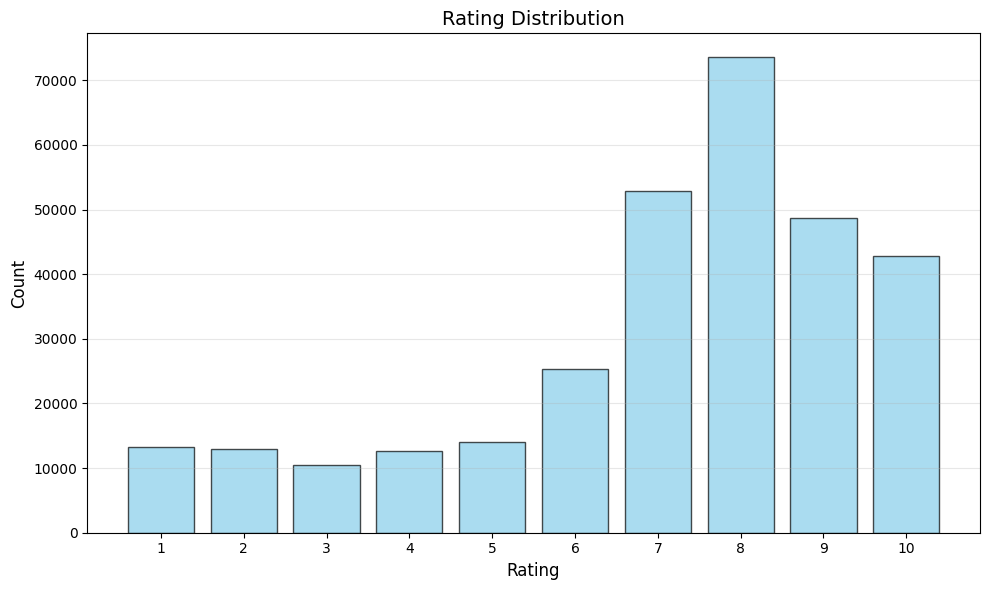

In [8]:
# 1. 평점별 빈도수 계산
rating_counts = ratings['rating'].value_counts().sort_index()

# 2. 결과 출력 (표)
print("=== 평점 분포 (Rating Distribution) ===")
print("-" * 40)
print(f"{'Rating':<6} | {'Count':>10} | {'Percentage':>10}")
print("-" * 40)

for rating, count in rating_counts.items():
    percentage = (count / len(ratings)) * 100
    print(f"{rating:<6} | {count:>10,} | {percentage:>9.2f}%")

print("-" * 40)
print(f"{'합계':>6} | {len(ratings):>10,} | {100.0:>7.2f}%")

print(f"\n평균 평점: {ratings['rating'].mean():.3f}")
print(f"중앙값: {ratings['rating'].median():.1f}")
print(f"표준편차: {ratings['rating'].std():.3f}")

# === 평점 분포 그래프 ===
plt.figure(figsize=(10, 6))
plt.bar(rating_counts.index, rating_counts.values, alpha=0.7, edgecolor='black', color='skyblue')

plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Rating Distribution', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rating_counts.index)

plt.tight_layout()
plt.show()

# 언어 검사

In [12]:
print(books['language'].unique())

['en' nan 'de' 'fr' 'es' 'ca' 'it' 'da' 'nl' 'pt' 'ro' 'no' 'ms' 'la' 'ru'
 'el' 'zh-CN' 'th' 'gl' 'ja' 'fa' 'eo' 'gd' 'ga' 'vi' 'zh-TW' 'ko']


In [3]:
# 2. 언어별 개수 확인 (상위 20개)
lang_counts = books['language'].value_counts()
print("=== 존재하는 언어 코드 및 개수 (Top 30) ===")
print(lang_counts.head(20))

=== 존재하는 언어 코드 및 개수 (Top 30) ===
language
en       78823
de        1282
es        1017
fr         883
it         123
nl          67
pt          47
da          37
ca          23
ms          10
no           6
zh-CN        3
la           3
ru           3
ja           3
gl           3
ro           1
el           1
th           1
fa           1
Name: count, dtype: int64


# Matrix Sparsity 검사

In [4]:
# 1. 고유 유저 수와 책 수 계산 (Matrix의 가로 세로 길이)
n_users = df['user_id'].nunique()
n_books = df['isbn'].nunique()

# 2. 실제 존재하는 평점의 개수 (0점 제외한 데이터 수)
n_ratings = len(df)

# 3. 전체 행렬의 크기 (모든 유저가 모든 책을 읽었을 경우)
total_cells = n_users * n_books

# 4. 희소성(Sparsity) 계산
# (비어있는 칸의 비율) = 1 - (채워진 칸의 비율)
sparsity = 1 - (n_ratings / total_cells)

print(f"=== Matrix Sparsity Analysis ===")
print(f"Total Users: {n_users:,}")
print(f"Total Books: {n_books:,}")
print(f"Total Ratings: {n_ratings:,}")
print(f"Total Possible Interactions: {total_cells:,}")
print(f"-" * 30)
print(f"👉 Sparsity: {sparsity * 100:.4f}%")
print(f"👉 Density:  {(1-sparsity) * 100:.4f}%")

=== Matrix Sparsity Analysis ===
Total Users: 59,803
Total Books: 129,777
Total Ratings: 306,795
Total Possible Interactions: 7,761,053,931
------------------------------
👉 Sparsity: 99.9960%
👉 Density:  0.0040%


# OOB 검사

In [7]:
test_ratings = pd.read_csv(data_path+'test_ratings.csv')

# 고유 유저 및 아이템 집합 추출
train_users = set(ratings['user_id'].unique())
train_isbns = set(ratings['isbn'].unique())

test_users = set(test_ratings['user_id'].unique())
test_isbns = set(test_ratings['isbn'].unique())

# OOB (Out-of-Bounds) / New users and items 찾기
new_users = test_users - train_users
new_isbns = test_isbns - train_isbns

# ---------------------------------------------------------
# 분석 1: 유저(User) 통계
# ---------------------------------------------------------
num_new_users = len(new_users)
ratio_new_users = (num_new_users / len(test_users)) * 100
# 영향받는 행(Row) 수 계산
rows_with_new_users = test_ratings[test_ratings['user_id'].isin(new_users)].shape[0]
ratio_rows_new_users = (rows_with_new_users / len(test_ratings)) * 100

print("=== 👤 OOB 유저 (New Users in Test) 확인 ===")
print(f"Test 셋의 총 유저 수: {len(test_users):,}명")
print(f"Train 셋에 없는 신규 유저 수: {num_new_users:,}명")
print(f"👉 신규 유저 비율 (Unique 기준): {ratio_new_users:.2f}%")
print(f"👉 신규 유저 관련 행 비율 (Row 기준): {ratio_rows_new_users:.2f}%")


# ---------------------------------------------------------
# 분석 2: 책(ISBN) 통계
# ---------------------------------------------------------
num_new_isbns = len(new_isbns)
ratio_new_isbns = (num_new_isbns / len(test_isbns)) * 100
rows_with_new_isbns = test_ratings[test_ratings['isbn'].isin(new_isbns)].shape[0]
ratio_rows_new_isbns = (rows_with_new_isbns / len(test_ratings)) * 100

print("\n=== 📚 OOB 책 (New Items in Test) 확인 ===")
print(f"Test 셋의 총 책 수: {len(test_isbns):,}권")
print(f"Train 셋에 없는 신규 책 수: {num_new_isbns:,}권")
print(f"👉 신규 책 비율 (Unique 기준): {ratio_new_isbns:.2f}%")
print(f"👉 신규 책 관련 행 비율 (Row 기준): {ratio_rows_new_isbns:.2f}%")


# ---------------------------------------------------------
# [추가된 부분] 분석 3: 완전 콜드 스타트 (Complete Cold Start)
# 유저와 책 모두 처음 보는 경우 -> 협업 필터링 절대 불가
# ---------------------------------------------------------
both_oob_df = test_ratings[
    (test_ratings['user_id'].isin(new_users)) & 
    (test_ratings['isbn'].isin(new_isbns))
]
both_oob_count = len(both_oob_df)
both_oob_ratio = both_oob_count / len(test_ratings) * 100

print("\n=== 🥶 완전 콜드 스타트 (Complete Cold Start) 확인 ===")
print(f"조건: 학습 데이터에 없는 유저가 AND 학습 데이터에 없는 책을 평가한 경우")
print(f"해당 케이스 수: {both_oob_count:,}건")
print(f"전체 테스트 데이터 대비 비율: {both_oob_ratio:.2f}%")

=== 👤 OOB 유저 (New Users in Test) 확인 ===
Test 셋의 총 유저 수: 26,167명
Train 셋에 없는 신규 유저 수: 8,266명
👉 신규 유저 비율 (Unique 기준): 31.59%
👉 신규 유저 관련 행 비율 (Row 기준): 11.31%

=== 📚 OOB 책 (New Items in Test) 확인 ===
Test 셋의 총 책 수: 52,000권
Train 셋에 없는 신규 책 수: 19,793권
👉 신규 책 비율 (Unique 기준): 38.06%
👉 신규 책 관련 행 비율 (Row 기준): 25.81%

=== 🥶 완전 콜드 스타트 (Complete Cold Start) 확인 ===
조건: 학습 데이터에 없는 유저가 AND 학습 데이터에 없는 책을 평가한 경우
해당 케이스 수: 1,734건
전체 테스트 데이터 대비 비율: 2.26%


# Interaction 검사

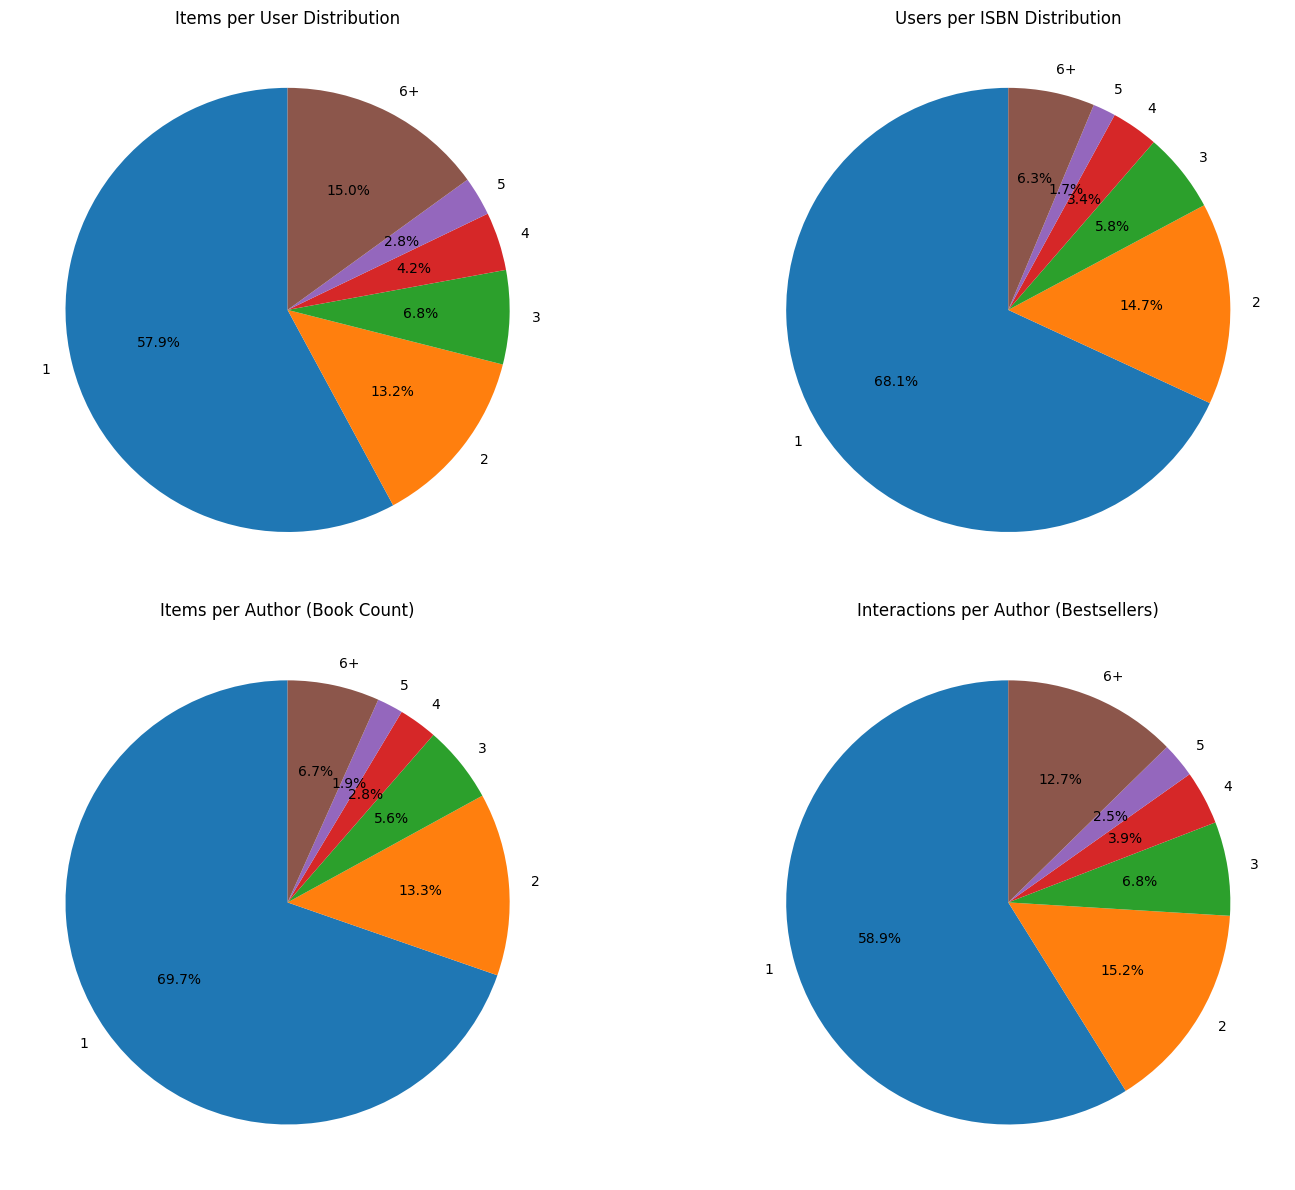

<Figure size 640x480 with 0 Axes>

In [18]:

# 유저당 아이템(책) 수
user_item_counts = df.groupby('user_id')['isbn'].nunique()

# ISBN당 유저 수
isbn_user_counts = df.groupby('isbn')['user_id'].nunique()

# Author당 아이템(책) 수
author_item_counts = df.groupby('book_author')['isbn'].nunique()

# Author당 interaction 수
author_interaction_counts = df.groupby('book_author').size()

# === 원형 그래프 (1~5, 6+) ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Items per User
user_pie_data = []
user_pie_labels = []
for i in range(1, 6):
    count = (user_item_counts == i).sum()
    user_pie_data.append(count)
    user_pie_labels.append(f'{i}')
user_pie_data.append((user_item_counts >= 6).sum())
user_pie_labels.append('6+')

axes[0, 0].pie(user_pie_data, labels=user_pie_labels, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Items per User Distribution')

# Users per ISBN
isbn_pie_data = []
isbn_pie_labels = []
for i in range(1, 6):
    count = (isbn_user_counts == i).sum()
    isbn_pie_data.append(count)
    isbn_pie_labels.append(f'{i}')
isbn_pie_data.append((isbn_user_counts >= 6).sum())
isbn_pie_labels.append('6+')

axes[0, 1].pie(isbn_pie_data, labels=isbn_pie_labels, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Users per ISBN Distribution')

# Items per Author (책 개수 - 다작)
author_items_pie_data = []
author_items_pie_labels = []
for i in range(1, 6):
    count = (author_item_counts == i).sum()
    author_items_pie_data.append(count)
    author_items_pie_labels.append(f'{i}')
author_items_pie_data.append((author_item_counts >= 6).sum())
author_items_pie_labels.append('6+')

axes[1, 0].pie(author_items_pie_data, labels=author_items_pie_labels, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Items per Author (Book Count)')

# Interactions per Author (읽힌 수 - 베스트셀러)
author_int_pie_data = []
author_int_pie_labels = []
for i in range(1, 6):
    count = (author_interaction_counts == i).sum()
    author_int_pie_data.append(count)
    author_int_pie_labels.append(f'{i}')
author_int_pie_data.append((author_interaction_counts >= 6).sum())
author_int_pie_labels.append('6+')

axes[1, 1].pie(author_int_pie_data, labels=author_int_pie_labels, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Interactions per Author (Bestsellers)')

plt.tight_layout()
plt.show()

# === 6 이상 분포 (x축만

plt.tight_layout()
plt.show()